In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.tree import _tree

import warnings
warnings.filterwarnings('ignore')

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print("Dataset shape:", X.shape)
print("Class distribution:\n", y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} | Test: {X_test.shape[0]}")


Dataset shape: (569, 30)
Class distribution:
 target
1    357
0    212
Name: count, dtype: int64

Train: 455 | Test: 114


Random Forest
Accuracy : 0.9561
F1 Score : 0.9655
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



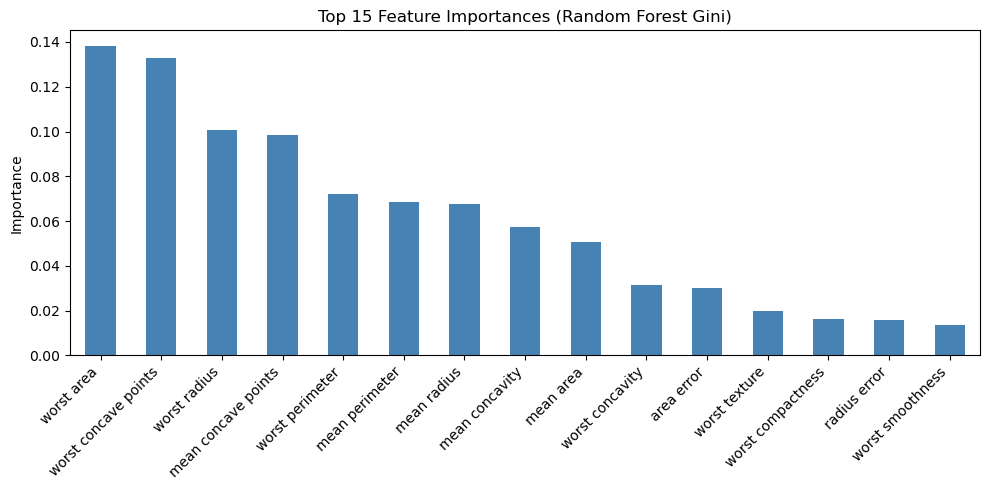

In [27]:
rf = RandomForestClassifier(
    n_estimators=100, max_depth=5, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)
rf_f1 = f1_score(y_test, rf_preds)

print("Random Forest")
print(f"Accuracy : {rf_acc:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(classification_report(y_test, rf_preds,
      target_names=["Malignant", "Benign"]))

importances = pd.Series(
    rf.feature_importances_, index=data.feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.head(15).plot(kind='bar', color='steelblue')
plt.title("Top 15 Feature Importances (Random Forest Gini)")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('rf_importances.png', dpi=150)
plt.show()


In [28]:
def extract_rules_from_tree(tree, feature_names):
    tree_ = tree.tree_
    features = [feature_names[i] if i != _tree.TREE_UNDEFINED
                else "undefined" for i in tree_.feature]
    rules = []

    def recurse(node, conditions):
        if tree_.feature[node] == _tree.TREE_UNDEFINED:
            class_counts = tree_.value[node][0]
            prediction = int(np.argmax(class_counts))
            rules.append({
                'conditions': list(conditions),
                'prediction': prediction,
                'samples': int(tree_.n_node_samples[node]),
                'impurity': float(tree_.impurity[node])
            })
            return
        feat = features[node]
        threshold = tree_.threshold[node]
        recurse(tree_.children_left[node],
                conditions + [f"{feat} <= {threshold:.4f}"])
        recurse(tree_.children_right[node],
                conditions + [f"{feat} > {threshold:.4f}"])

    recurse(0, [])
    return rules


all_rules = []
for estimator in rf.estimators_:
    all_rules.extend(
        extract_rules_from_tree(estimator, list(data.feature_names))
    )

# only keep rules from leaves that are mostly one class
clean_rules = [r for r in all_rules if r['impurity'] < 0.1]
print(f"Total rules extracted : {len(all_rules)}")
print(f"After purity filter   : {len(clean_rules)}")
print(f"\nExample rule:")
print(f"  IF {chr(10)+'  AND '.join(clean_rules[0]['conditions'])}")
print(f"  THEN -> {'Benign' if clean_rules[0]['prediction']==1 else 'Malignant'}")


Total rules extracted : 1490
After purity filter   : 1368

Example rule:
  IF 
worst concave points <= 0.1509  AND radius error <= 0.5662  AND worst area <= 952.9000  AND mean concavity <= 0.0860  AND mean radius <= 15.0850
  THEN -> Benign


In [29]:
def instance_satisfies_rule(row, conditions):
    for condition in conditions:
        if ' <= ' in condition:
            feat, thresh = condition.split(' <= ')
            if not (row[feat.strip()] <= float(thresh)):
                return False
        elif ' > ' in condition:
            feat, thresh = condition.split(' > ')
            if not (row[feat.strip()] > float(thresh)):
                return False
    return True


def build_indicator_matrix(rules, X_df):
    N = len(X_df)
    K = len(rules)
    A = np.zeros((N, K), dtype=np.float32)
    for k, rule in enumerate(rules):
        if k % 500 == 0:
            print(f"  Rule {k}/{K}...")
        for i, (_, row) in enumerate(X_df.iterrows()):
            if instance_satisfies_rule(row, rule['conditions']):
                A[i, k] = 1.0
    return A


print("Building A_train matrix...")
A_train = build_indicator_matrix(clean_rules, X_train.reset_index(drop=True))
print("Building A_test matrix...")
A_test = build_indicator_matrix(clean_rules, X_test.reset_index(drop=True))
print(f"\nA_train shape: {A_train.shape}")
print(f"A_test shape : {A_test.shape}")
print(f"Matrix density: {A_train.mean():.4f}")


Building A_train matrix...
  Rule 0/1368...
  Rule 500/1368...
  Rule 1000/1368...
Building A_test matrix...
  Rule 0/1368...
  Rule 500/1368...
  Rule 1000/1368...

A_train shape: (455, 1368)
A_test shape : (114, 1368)
Matrix density: 0.0707


In [30]:
print("Running LassoCV to find a good lambda...")
lasso_cv = LassoCV(cv=5, max_iter=10000, random_state=42, n_alphas=100)
lasso_cv.fit(A_train, y_train.values)
best_alpha = lasso_cv.alpha_
print(f"Best lambda: {best_alpha:.6f}")

lasso = Lasso(alpha=best_alpha, max_iter=10000)
lasso.fit(A_train, y_train.values)

nonzero_mask = lasso.coef_ != 0
nonzero_indices = np.where(nonzero_mask)[0]
nonzero_weights = lasso.coef_[nonzero_mask]

sparse_rules = []
for idx, weight in zip(nonzero_indices, nonzero_weights):
    rule = clean_rules[idx].copy()
    rule['weight'] = weight
    sparse_rules.append(rule)
sparse_rules.sort(key=lambda r: abs(r['weight']), reverse=True)

print(f"\nRules before Lasso : {len(clean_rules)}")
print(f"Rules after Lasso  : {len(sparse_rules)}")
print(f"Compression        : {100*(1-len(sparse_rules)/len(clean_rules)):.1f}%")

print("\nFinal sparse rule set")
for i, rule in enumerate(sparse_rules):
    label = 'Benign' if rule['prediction'] == 1 else 'Malignant'
    print(f"\nRule {i+1} | weight={rule['weight']:.4f} | "
          f"class={label} | samples={rule['samples']}")
    for cond in rule['conditions']:
        print(f"  IF {cond}")
    print(f"  THEN -> {label}")

# try stricter lambdas to push the rule count down
for multiplier in [2, 5, 10, 20, 30]:
    lasso_strict = Lasso(alpha=best_alpha * multiplier, max_iter=10000)
    lasso_strict.fit(A_train, y_train.values)

    n_rules = np.sum(lasso_strict.coef_ != 0)
    preds = lasso_strict.predict(A_test) >= 0.5
    acc = accuracy_score(y_test, preds.astype(int))

    print(f"Lambda x{multiplier:>3} -> {n_rules:>4} rules | "
          f"Accuracy: {acc:.4f}")


Running LassoCV to find a good lambda...
Best lambda: 0.000420

Rules before Lasso : 1368
Rules after Lasso  : 163
Compression        : 88.1%

Final sparse rule set

Rule 1 | weight=-0.3331 | class=Malignant | samples=7
  IF mean concave points <= 0.0514
  IF area error > 40.2200
  IF compactness error <= 0.0164
  IF smoothness error <= 0.0070
  IF mean smoothness > 0.0802
  THEN -> Malignant

Rule 2 | weight=-0.1669 | class=Malignant | samples=14
  IF mean perimeter <= 96.4050
  IF worst concave points > 0.1358
  IF worst perimeter > 90.9500
  IF mean fractal dimension > 0.0611
  IF mean radius <= 14.4300
  THEN -> Malignant

Rule 3 | weight=-0.1588 | class=Malignant | samples=1
  IF mean concavity <= 0.0905
  IF perimeter error <= 3.9345
  IF worst radius <= 16.8300
  IF mean concave points > 0.0268
  IF mean concave points <= 0.0272
  THEN -> Malignant

Rule 4 | weight=-0.1552 | class=Malignant | samples=2
  IF mean radius <= 14.6600
  IF worst concavity <= 0.3703
  IF texture error

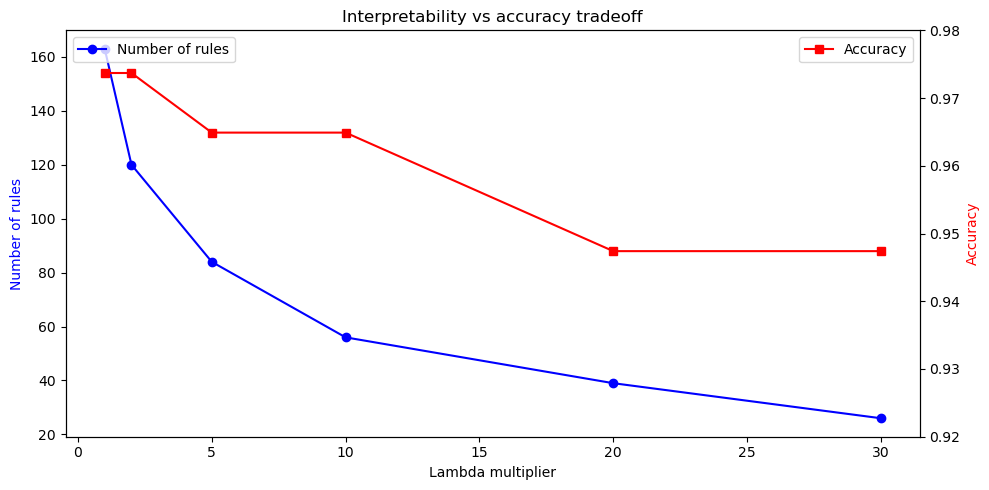

In [31]:
multipliers = [1, 2, 5, 10, 20, 30]
rule_counts = [163, 120, 84, 56, 39, 26]
accuracies = [0.9737, 0.9737, 0.9649, 0.9649, 0.9474, 0.9474]

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(multipliers, rule_counts, 'bo-', label='Number of rules')
ax2.plot(multipliers, accuracies, 'rs-', label='Accuracy')

ax1.set_xlabel('Lambda multiplier')
ax1.set_ylabel('Number of rules', color='blue')
ax2.set_ylabel('Accuracy', color='red')
ax2.set_ylim(0.92, 0.98)

plt.title('Interpretability vs accuracy tradeoff')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('tradeoff_curve.png', dpi=150)
plt.show()


In [32]:
chosen_multiplier = 30

lasso = Lasso(alpha=best_alpha * chosen_multiplier, max_iter=10000)
lasso.fit(A_train, y_train.values)

nonzero_mask = lasso.coef_ != 0
nonzero_indices = np.where(nonzero_mask)[0]
nonzero_weights = lasso.coef_[nonzero_mask]

sparse_rules = []
for idx, weight in zip(nonzero_indices, nonzero_weights):
    rule = clean_rules[idx].copy()
    rule['weight'] = weight
    sparse_rules.append(rule)
sparse_rules.sort(key=lambda r: abs(r['weight']), reverse=True)

print(f"Final rule count : {len(sparse_rules)}")


Final rule count : 26


In [33]:
def predict_with_rules(sparse_rules, X_df, intercept):
    predictions = []
    fired_counts = []
    for _, row in X_df.iterrows():
        score = intercept
        fired = 0
        for rule in sparse_rules:
            if instance_satisfies_rule(row, rule['conditions']):
                score += rule['weight']
                fired += 1
        predictions.append(1 if score >= 0.5 else 0)
        fired_counts.append(fired)
    return np.array(predictions), fired_counts


print("Predicting with sparse rules...")
rule_preds, fired_counts = predict_with_rules(
    sparse_rules, X_test.reset_index(drop=True), lasso.intercept_
)
rule_acc = accuracy_score(y_test, rule_preds)
rule_f1 = f1_score(y_test, rule_preds)

print("\nPerformance comparison")
print(f"{'Model':<40} {'Acc':>8} {'F1':>8}")
print(f"{'Random Forest (100 trees)':<40} "
      f"{rf_acc:>8.4f} {rf_f1:>8.4f}")
print(f"{'Sparse Rules (' + str(len(sparse_rules)) + ' rules)':<40} "
      f"{rule_acc:>8.4f} {rule_f1:>8.4f}")
print(f"\nAccuracy cost of interpretability: "
      f"{(rf_acc-rule_acc)*100:.2f}%")
print(classification_report(y_test, rule_preds,
      target_names=["Malignant", "Benign"]))


Predicting with sparse rules...

Performance comparison
Model                                         Acc       F1
Random Forest (100 trees)                  0.9561   0.9655
Sparse Rules (26 rules)                    0.9474   0.9583

Accuracy cost of interpretability: 0.88%
              precision    recall  f1-score   support

   Malignant       0.93      0.93      0.93        42
      Benign       0.96      0.96      0.96        72

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



Signal vs noise
Features in sparse rules : 28
Top RF Gini features     : 28
Overlap                  : 26
Overlap %                : 93%

Features both methods agree on:
  - area error
  - compactness error
  - concave points error
  - concavity error
  - fractal dimension error
  - mean area
  - mean concave points
  - mean concavity
  - mean fractal dimension
  - mean perimeter
  - mean radius
  - mean texture
  - perimeter error
  - radius error
  - smoothness error
  - texture error
  - worst area
  - worst compactness
  - worst concave points
  - worst concavity
  - worst fractal dimension
  - worst perimeter
  - worst radius
  - worst smoothness
  - worst symmetry
  - worst texture


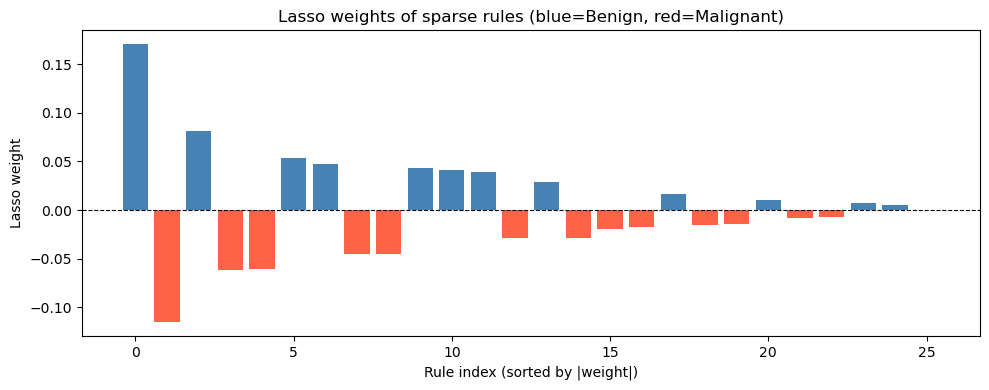

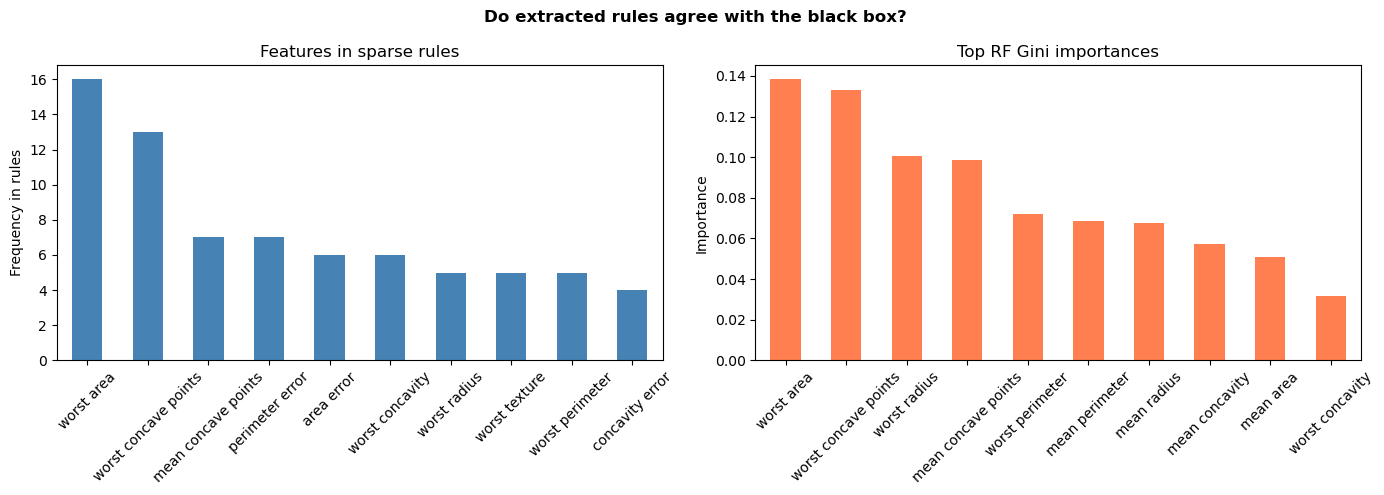


Summary
Started with         : 100-tree Random Forest
Extracted            : 1490 candidate rules
After purity filter  : 1368 clean rules
After Lasso (L1)     : 26 interpretable rules
RF accuracy          : 0.9561
Rule set accuracy    : 0.9474
Accuracy retained    : 99.1%
Rules firing/instance: 10.8 on average


In [34]:
# which features show up inside the sparse rules?
rule_features = []
for rule in sparse_rules:
    for cond in rule['conditions']:
        feat = cond.split(' <= ')[0].strip() if ' <= ' in cond \
               else cond.split(' > ')[0].strip()
        rule_features.append(feat)
rule_feat_counts = pd.Series(rule_features).value_counts()

rule_feat_set = set(rule_feat_counts.index)
rf_feat_set = set(importances.head(len(rule_feat_set)).index)
overlap = rule_feat_set & rf_feat_set

print("Signal vs noise")
print(f"Features in sparse rules : {len(rule_feat_set)}")
print(f"Top RF Gini features     : {len(rf_feat_set)}")
print(f"Overlap                  : {len(overlap)}")
print(f"Overlap %                : "
      f"{100*len(overlap)/len(rule_feat_set):.0f}%")
print(f"\nFeatures both methods agree on:")
for f in sorted(overlap):
    print(f"  - {f}")

# rule weights
plt.figure(figsize=(10, 4))
weights = [r['weight'] for r in sparse_rules]
colors = ['steelblue' if r['prediction']==1 else 'tomato'
          for r in sparse_rules]
plt.bar(range(len(sparse_rules)), weights, color=colors)
plt.axhline(0, color='black', lw=0.8, ls='--')
plt.xlabel("Rule index (sorted by |weight|)")
plt.ylabel("Lasso weight")
plt.title("Lasso weights of sparse rules (blue=Benign, red=Malignant)")
plt.tight_layout()
plt.savefig('rule_weights.png', dpi=150)
plt.show()

# features in rules vs RF importances
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rule_feat_counts.head(10).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title("Features in sparse rules")
axes[0].set_ylabel("Frequency in rules")
axes[0].tick_params(axis='x', rotation=45)

importances.head(10).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title("Top RF Gini importances")
axes[1].set_ylabel("Importance")
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Do extracted rules agree with the black box?",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('signal_vs_noise.png', dpi=150)
plt.show()

print("\nSummary")
print(f"Started with         : 100-tree Random Forest")
print(f"Extracted            : {len(all_rules)} candidate rules")
print(f"After purity filter  : {len(clean_rules)} clean rules")
print(f"After Lasso (L1)     : {len(sparse_rules)} interpretable rules")
print(f"RF accuracy          : {rf_acc:.4f}")
print(f"Rule set accuracy    : {rule_acc:.4f}")
print(f"Accuracy retained    : {rule_acc/rf_acc*100:.1f}%")
print(f"Rules firing/instance: {np.mean(fired_counts):.1f} on average")


In [35]:
# 30 features from the breast cancer dataset taken as template
# jsut for using as a custm patient
test_patient = {
    'mean radius'            : 17.99,
    'mean texture'           : 10.38,
    'mean perimeter'         : 122.8,
    'mean area'              : 1001.0,
    'mean smoothness'        : 0.1184,
    'mean compactness'       : 0.2776,
    'mean concavity'         : 0.3001,
    'mean concave points'    : 0.1471,
    'mean symmetry'          : 0.2419,
    'mean fractal dimension' : 0.07871,
    'radius error'           : 1.095,
    'texture error'          : 0.9053,
    'perimeter error'        : 8.589,
    'area error'             : 153.4,
    'smoothness error'       : 0.006399,
    'compactness error'      : 0.04904,
    'concavity error'        : 0.05373,
    'concave points error'   : 0.01587,
    'symmetry error'         : 0.03003,
    'fractal dimension error': 0.006193,
    'worst radius'           : 25.38,
    'worst texture'          : 17.33,
    'worst perimeter'        : 184.6,
    'worst area'             : 2019.0,
    'worst smoothness'       : 0.1622,
    'worst compactness'      : 0.6656,
    'worst concavity'        : 0.7119,
    'worst concave points'   : 0.2654,
    'worst symmetry'         : 0.4601,
    'worst fractal dimension': 0.1189,
}

row = pd.Series(test_patient)
score = lasso.intercept_
fired_rules = []

for rule in sparse_rules:
    if instance_satisfies_rule(row, rule['conditions']):
        score += rule['weight']
        fired_rules.append(rule)

prediction = 'MALIGNANT' if score < 0.5 else 'BENIGN'
confidence = abs(score - 0.5) * 100

print(f"PREDICTION  :  {prediction}")
print(f"Confidence  :  {confidence:.1f}  (distance from boundary)")
print(f"Raw score   :  {score:.4f}  (< 0.5 = Malignant)")

print(f"\n{len(fired_rules)} rules fired for this patient:\n")
for i, rule in enumerate(fired_rules):
    label = 'BENIGN' if rule['prediction'] == 1 else 'MALIGNANT'
    direction = 'pushing toward BENIGN' if rule['weight'] > 0 \
                else 'pushing toward MALIGNANT'
    print(f"Rule {i+1} [{label}] weight={rule['weight']:+.4f} {direction}")
    for cond in rule['conditions']:
        print(f"   IF {cond}")
    print()

# now test on a known benign patient from the test set
print("\nKnown benign patient from test set")

benign_idx = y_test[y_test == 1].index[0]
benign_row = X_test.loc[benign_idx]
score2 = lasso.intercept_
fired_rules2 = []

for rule in sparse_rules:
    if instance_satisfies_rule(benign_row, rule['conditions']):
        score2 += rule['weight']
        fired_rules2.append(rule)

pred2 = 'MALIGNANT' if score2 < 0.5 else 'BENIGN'
print(f"PREDICTION  : {pred2}")
print(f"Raw score   : {score2:.4f}")
print(f"Rules fired : {len(fired_rules2)}")

# and a known malignant patient
print("\nKnown malignant patient from test set")

malig_idx = y_test[y_test == 0].index[0]
malig_row = X_test.loc[malig_idx]
score3 = lasso.intercept_
fired_rules3 = []

for rule in sparse_rules:
    if instance_satisfies_rule(malig_row, rule['conditions']):
        score3 += rule['weight']
        fired_rules3.append(rule)

pred3 = 'MALIGNANT' if score3 < 0.5 else 'BENIGN'
print(f"PREDICTION  : {pred3}")
print(f"Raw score   : {score3:.4f}")
print(f"Rules fired : {len(fired_rules3)}")


PREDICTION  :  MALIGNANT
Confidence  :  25.3  (distance from boundary)
Raw score   :  0.2469  (< 0.5 = Malignant)

8 rules fired for this patient:

Rule 1 [MALIGNANT] weight=-0.0608 pushing toward MALIGNANT
   IF worst concave points > 0.1359
   IF concavity error <= 0.1215
   IF worst perimeter > 89.9500
   IF texture error > 0.5235

Rule 2 [MALIGNANT] weight=-0.0454 pushing toward MALIGNANT
   IF worst area > 750.0500
   IF worst concavity > 0.2070
   IF worst concave points > 0.1067
   IF mean concave points > 0.0316
   IF perimeter error > 1.2435

Rule 3 [MALIGNANT] weight=-0.0449 pushing toward MALIGNANT
   IF worst area > 874.8500
   IF fractal dimension error > 0.0016
   IF perimeter error > 2.0345

Rule 4 [MALIGNANT] weight=-0.0197 pushing toward MALIGNANT
   IF mean concave points > 0.0514
   IF mean concavity > 0.0905
   IF worst perimeter > 90.3800
   IF concavity error <= 0.1300
   IF worst smoothness > 0.1061

Rule 5 [MALIGNANT] weight=-0.0177 pushing toward MALIGNANT
   I

In [36]:
# detailed breakdown of which rules fired for the benign patient
print("Known benign patient")
print(f"PREDICTION  : {pred2}")
print(f"Raw score   : {score2:.4f}")
print(f"Rules fired : {len(fired_rules2)}\n")

for i, rule in enumerate(fired_rules2):
    label = 'BENIGN' if rule['prediction'] == 1 else 'MALIGNANT'
    direction = 'pushing toward BENIGN' if rule['weight'] > 0 \
                else 'pushing toward MALIGNANT'
    print(f"Rule {i+1} [{label}] weight={rule['weight']:+.4f} {direction}")
    for cond in rule['conditions']:
        print(f"   IF {cond}")
    print()

# same breakdown for the malignant patient
print("\nKnown malignant patient")
print(f"PREDICTION  : {pred3}")
print(f"Raw score   : {score3:.4f}")
print(f"Rules fired : {len(fired_rules3)}\n")

for i, rule in enumerate(fired_rules3):
    label = 'BENIGN' if rule['prediction'] == 1 else 'MALIGNANT'
    direction = 'pushing toward BENIGN' if rule['weight'] > 0 \
                else 'pushing toward MALIGNANT'
    print(f"Rule {i+1} [{label}] weight={rule['weight']:+.4f} {direction}")
    for cond in rule['conditions']:
        print(f"   IF {cond}")
    print()


Known benign patient
PREDICTION  : BENIGN
Raw score   : 1.0065
Rules fired : 12

Rule 1 [BENIGN] weight=+0.1703 pushing toward BENIGN
   IF worst radius <= 17.3850
   IF worst concavity <= 0.5041
   IF worst concave points <= 0.1464
   IF radius error <= 1.0475
   IF worst concavity <= 0.3787

Rule 2 [BENIGN] weight=+0.0813 pushing toward BENIGN
   IF worst area <= 884.7500
   IF worst concave points <= 0.1603
   IF area error <= 91.5550
   IF worst area <= 830.7000
   IF worst texture <= 29.9100

Rule 3 [BENIGN] weight=+0.0533 pushing toward BENIGN
   IF worst area <= 750.0500
   IF worst concave points <= 0.1807
   IF radius error <= 0.6256
   IF mean perimeter <= 93.0100

Rule 4 [BENIGN] weight=+0.0473 pushing toward BENIGN
   IF worst area <= 884.7500
   IF worst fractal dimension <= 0.0933
   IF concave points error <= 0.0176
   IF smoothness error > 0.0033
   IF area error <= 48.7000

Rule 5 [BENIGN] weight=+0.0434 pushing toward BENIGN
   IF worst radius <= 16.7950
   IF worst c

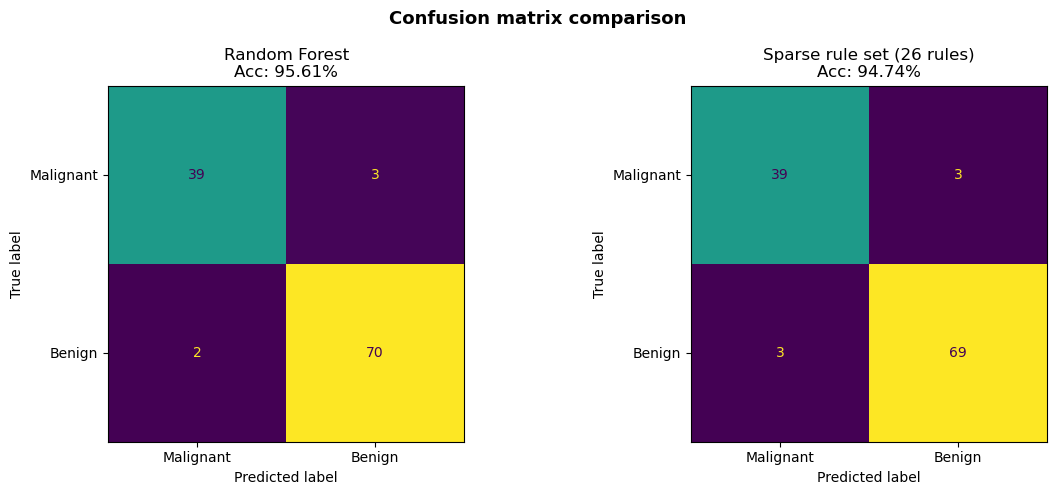

All 26 extracted rules

Rule 01 | BENIGN | weight=+0.1703
  Conditions:
    - worst radius <= 17.3850
    - worst concavity <= 0.5041
    - worst concave points <= 0.1464
    - radius error <= 1.0475
    - worst concavity <= 0.3787
  -> Prediction: BENIGN

Rule 02 | MALIGNANT | weight=-0.1153
  Conditions:
    - mean concave points > 0.0504
    - worst texture > 20.8750
    - worst perimeter > 102.5500
    - mean fractal dimension <= 0.0773
  -> Prediction: MALIGNANT

Rule 03 | BENIGN | weight=+0.0813
  Conditions:
    - worst area <= 884.7500
    - worst concave points <= 0.1603
    - area error <= 91.5550
    - worst area <= 830.7000
    - worst texture <= 29.9100
  -> Prediction: BENIGN

Rule 04 | MALIGNANT | weight=-0.0613
  Conditions:
    - worst area > 810.5000
    - mean texture > 14.0950
    - worst concave points > 0.0850
    - perimeter error > 1.2450
    - worst concavity > 0.2181
  -> Prediction: MALIGNANT

Rule 05 | MALIGNANT | weight=-0.0608
  Conditions:
    - worst con

In [37]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm1 = confusion_matrix(y_test, rf_preds)
cm2 = confusion_matrix(y_test, rule_preds)

ConfusionMatrixDisplay(cm1, display_labels=['Malignant', 'Benign'])\
    .plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Random Forest\nAcc: {rf_acc*100:.2f}%')

ConfusionMatrixDisplay(cm2, display_labels=['Malignant', 'Benign'])\
    .plot(ax=axes[1], colorbar=False)
axes[1].set_title(f'Sparse rule set ({len(sparse_rules)} rules)\n'
                  f'Acc: {rule_acc*100:.2f}%')

plt.suptitle('Confusion matrix comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

# full list of selected rules
print(f"All {len(sparse_rules)} extracted rules")
for i, rule in enumerate(sparse_rules):
    label = 'BENIGN' if rule['prediction'] == 1 else 'MALIGNANT'
    print(f"\nRule {i+1:02d} | {label} | weight={rule['weight']:+.4f}")
    print("  Conditions:")
    for cond in rule['conditions']:
        print(f"    - {cond}")
    print(f"  -> Prediction: {label}")
